In [42]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from scipy import linalg as LA
import random
import numpy.matlib
import kwant
import tinyarray
import multiprocessing as mp
import os
from tqdm import tqdm
import helpers as hp
from pathlib import Path
from config import PathConfigs
import scipy.sparse.linalg as sla
import multiprocessing as mp
from functools import partial
from scipy.signal import find_peaks
import itertools as itr

#pauli matrices
sigma_0 = tinyarray.array([[1, 0], [0, 1]])
sigma_x = tinyarray.array([[0, 1], [1, 0]])
sigma_y = tinyarray.array([[0, -1j], [1j, 0]])
sigma_z = tinyarray.array([[1, 0], [0, -1]])

In [43]:
def build_system_closed(t, mu, gamma, Delta0, V_z, alpha, Ls, Vdisx, a=1):
    # Strictly the SM-SC region (Open Boundary Conditions, no barriers/leads)
    
    syst = kwant.Builder()
    lat = kwant.lattice.square(a, norbs=4)
    
    Z = Delta0 / (Delta0 + gamma)
    
    # Calculate the finite-size corrected band bottom
    epsilon0 = 2 * t * np.cos(np.pi / (Ls + 1.0))
    
    mu_s = np.zeros(Ls)
        
    for i in range(Ls):
        mu_s[i] = mu - Vdisx[i]

    # 1. Superconductor (Renormalized) - Only region left
    for i in range(Ls):
        # Replaced 2 * t with epsilon0
        syst[lat(i, 0)] = Z * (epsilon0 - mu_s[i]) * np.kron(sigma_z, sigma_0) \
                          + Z * V_z * np.kron(sigma_0, sigma_x) \
                          + Z * gamma * np.kron(sigma_x, sigma_0) 
        
        if i > 0: 
            # Uniform hopping throughout the pure SM-SC wire
            syst[lat(i, 0), lat(i-1, 0)] = Z * (-t * np.kron(sigma_z, sigma_0) + 0.5*1j*alpha * np.kron(sigma_z, sigma_y))
    
    return syst.finalized()

In [44]:
dirname = Path(PathConfigs.DATA/"spectra_fix"/"Tdis_nb")
all_params = np.load(Path(dirname, 'all_params.npz'))
params_list = np.load(Path(dirname, 'params_list.npy'))

Vz_var = all_params['Vz_var']

V0 = all_params['V0']

Vdisx = hp.np_load_wrapped("Vdisx", dirname)*V0

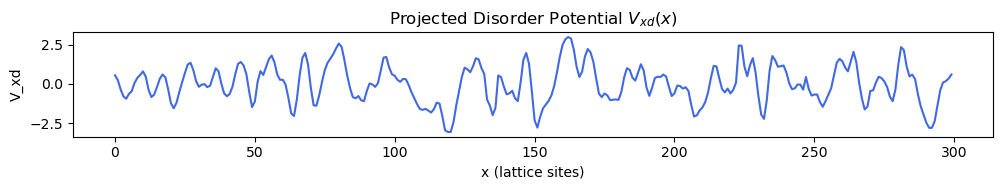

ΔVd = -0.0000
sqrt[<Vxd²>] = 1.2000


In [45]:
Nx = len(Vdisx)
plt.figure(figsize=(10, 2))
plt.plot(np.arange(Nx), Vdisx, color='royalblue')
plt.xlabel("x (lattice sites)")
plt.ylabel("V_xd")
plt.title("Projected Disorder Potential $V_{xd}(x)$")
plt.gca().set_aspect('auto')
plt.tight_layout()
plt.show()

# mean and variance
DeltaVd = np.mean(Vdisx)
VarVd = np.mean(Vdisx**2)
print(f"ΔVd = {DeltaVd:.4f}")
print(f"sqrt[<Vxd²>] = {np.sqrt(VarVd):.4f}")

In [46]:

#### constants: 
hbar = 6.582119569e-16  # eV·s
m0   = 9.10938356e-31  # kg
e0   = 1.602176634e-19   # C
eta_m = (hbar ** 2 * e0) * (1e20)/m0 # hbar^2/m0 in eV A^2
mu_B =  5.7883818066e-2  #in meV/T
meVpK = 8.6173325e-2 # Kelvin into meV 

In [47]:
#Ls = 300 # wire length
#
#Ln = 0 #length of normal region. See Dourado 2023
#a0 = 100 # unit cell in A
#ms = 0.023 # effective mass
#Lb=3
#t = 1000 * eta_m/(2 * a0**2 * ms) # hopping in meV
#alpha = 140.0/a0 # Rashba SOC
#
#Delta0= 0.3 # parent SC gap
#gamma = 0.2 # SM-SC coupling strength in meV
#Delta = Delta0 * gamma /(Delta0 + gamma) #induced gap
#
#mu_leads = t # lead chemical potential (meV)
#
#barrier0 = 5 #barrier energy (meV)
#
#V0 = 1.2#10.5 * Delta 
#
#Upoints = 20 
#num_engs = 101  
#
#mu_n = 0.0
#
#mu_max = 4.0
#mu_min = 1
#mu_rng = mu_max - mu_min
#mu_dist = 0.04 #spacing between points
#Nmu = int(mu_rng/mu_dist) #total number of paramter space points for mu
#mu_var = np.linspace(mu_min, mu_max, Nmu)
#
#Vz_max = 1.3
#Vz_min = 0.75
#Vz_rng = Vz_max - Vz_min
#Vz_dist = 0.02 #spacing between points
#Nvz = int(Vz_rng/Vz_dist)
#Vz_var = np.linspace(Vz_min, Vz_max, Nvz) 
#
#
#params_list = [pms for pms in itr.product(mu_var, Vz_var)]
#params_list = [[i, pms[0], pms[1]] for i, pms in enumerate(params_list)]
#
#
#barrier_arr = np.linspace(barrier0, 40*barrier0, Upoints)
#energies = np.linspace(-0.5, 0.5, num_engs)
#
#
#num_eigenvalues = 22 #number of eigenvalues to calculate in the low energy spectra, so 10 above and below the MZMs in this case

In [48]:
Ls = all_params['Ls'] # wire length

Ln = all_params['Ln'] # length of normal region. See Dourado 2023
a0 = all_params['a0'] # unit cell in A
ms = all_params['ms'] # effective mass
Lb = all_params['Lb']
t = all_params['t'] # hopping in meV
alpha = all_params['alpha'] # Rashba SOC

Delta0 = all_params['Delta0'] # parent SC gap
gamma = all_params['gamma'] # SM-SC coupling strength in meV

mu_leads = all_params['mu_leads'] # lead chemical potential (meV)

barrier0 = all_params['barrier0'] # barrier energy (meV)

Upoints = all_params['Upoints'] 
num_engs = all_params['num_engs']  

mu_n = all_params['mu_n']

mu_max = all_params['mu_max']
mu_min = all_params['mu_min']
mu_rng = all_params['mu_rng']
mu_dist = all_params['mu_dist'] # spacing between points
Nmu = all_params['Nmu'] # total number of parameter space points for mu
mu_var = all_params['mu_var']

Vz_max = all_params['Vz_max']
Vz_min = all_params['Vz_min']
Vz_rng = all_params['Vz_rng']
Vz_dist = all_params['Vz_dist'] # spacing between points
Nvz = all_params['Nvz']
Vz_var = all_params['Vz_var'] 

barrier_arr = all_params['barrier_arr']
energies = all_params['energies']

num_eigenvalues = all_params['num_eigenvalues'] # number of eigenvalues to calculate in the low energy spectra

gamma

array(0.2)

In [61]:
target_mu = 3.8772
V_z = 1.0

syst = build_system_closed(t, target_mu, gamma, Delta0, V_z, alpha, Ls,  Vdisx=Vdisx)
ham = syst.hamiltonian_submatrix(sparse=True)
print(f"Hamiltonian: {ham.shape}")

evals, evects = np.linalg.eigh(ham.todense())

Hamiltonian: (1200, 1200)


In [65]:
np.min(np.abs(evals))

0.010298387831222264

In [57]:
evals = hp.calc_spectrum(syst, k = 30)

evals

array([-0.33013526, -0.296515  , -0.28288704, -0.24766954, -0.22652495,
       -0.21389773, -0.19363422, -0.17448737, -0.15688517, -0.14345956,
       -0.12345013, -0.10644838, -0.0524135 , -0.02461106, -0.01029839,
        0.01029839,  0.02461106,  0.0524135 ,  0.10644838,  0.12345013,
        0.14345956,  0.15688517,  0.17448737,  0.19363422,  0.21389773,
        0.22652495,  0.24766954,  0.28288704,  0.296515  ,  0.33013526])

In [58]:
truth = np.asarray([0.01029839, 0.02461106, 0.0524135,  0.10644838, 0.12345013, 0.14345956,
 0.15688517, 0.17448737, 0.19363422, 0.21389773, 0.22652495, 0.24766954,
 0.28288704, 0.296515,   0.33013526])

In [59]:
evalset = np.unique(evals[evals > 0])
evalset[:15] - truth

array([-2.16877673e-09, -3.38837971e-09,  2.23903591e-09,  1.62208259e-09,
       -3.11308881e-10,  3.31422456e-09, -2.52303448e-09, -2.36519132e-09,
       -4.69511516e-09, -3.45354939e-10, -1.74696718e-09, -3.46694240e-09,
       -4.17612045e-09,  2.14715135e-09, -2.06525247e-09])

In [ ]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm # using notebook version for cleaner progress bar
import numpy as np

target_mu = 3.8772
Vz_var = np.linspace(0.02, 1.3, 100)

# 1. Define a wrapper function for the parallel workers
def compute_spectrum(V_z):
    # Variables like t, mu_n, gamma, etc. will be naturally captured from the notebook's global scope
    syst = hp.build_system_closed(t, target_mu, gamma, Delta0, V_z, alpha, Ls, Vdisx, a=1)
    return hp.calc_spectrum(syst)

# 2. Run the loop in parallel
# n_jobs=-1 tells it to use all available CPU cores
results = Parallel(n_jobs=8)(
    delayed(compute_spectrum)(V_z) for V_z in tqdm(Vz_var, desc="Calculating Spectrum")
)

# 3. Convert the list of results back to your desired array shape
spectrum = np.array(results) 
# spectrum will have shape (100, 22) automatically, in the exact order of Vz_var

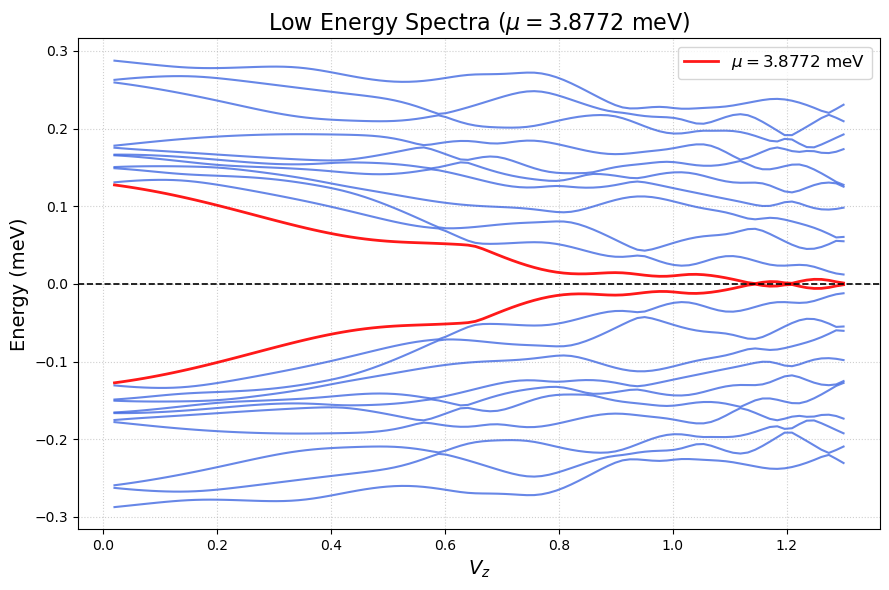

In [60]:

plot_vz = Vz_var
plot_spectra = spectrum

# 1. Create the Figure with a single subplot
fig, ax1 = plt.subplots(
    nrows=1, ncols=1, 
    figsize=(9, 6), # Adjusted height for a single plot
    dpi=100
)

# ---------------------------------------------------------
# TOP PLOT (ax1): Energy Spectrum
# ---------------------------------------------------------
# Plot the bulk states (using slicing to avoid re-plotting the middle states)
ax1.plot(plot_vz, plot_spectra[:, :10], color='royalblue', alpha=0.8, linewidth=1.5)
ax1.plot(plot_vz, plot_spectra[:, 12:], color='royalblue', alpha=0.8, linewidth=1.5)

# Plot the two states closest to E=0 in red (Majorana/Mid-gap states)
ax1.plot(plot_vz, plot_spectra[:, 10:12], color='red', alpha=0.9, linewidth=2.0, label=rf"$\mu = {target_mu}$ meV")

ax1.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax1.set_xlabel(r"$V_z$ ", fontsize=14) # Added X-axis label
ax1.set_ylabel("Energy (meV)", fontsize=14)
ax1.set_title(f"Low Energy Spectra ($\mu = {target_mu}$ meV)", fontsize=16)
ax1.grid(True, linestyle=':', alpha=0.6)

# Handle legend duplication
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:


plot_vz = Vz_var

plot_spectra = spectrum

# 6. Create the Figure with 2 Subplots
# gridspec_kw={'height_ratios': [3, 1]} makes the top plot 3x taller than the bottom
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, 
    figsize=(8, 8), 
    dpi=100, 
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]} 
)

# ---------------------------------------------------------
# TOP PLOT (ax1): Energy Spectrum
# ---------------------------------------------------------
# Plot the bulk states in standard blue
ax1.plot(plot_vz, plot_spectra[:, :10], color='royalblue', alpha=0.8, linewidth=1.5)
ax1.plot(plot_vz, plot_spectra[:, 12:], color='royalblue', alpha=0.8, linewidth=1.5)

# Plot the two states closest to E=0 in red. 
ax1.plot(plot_vz, plot_spectra[:, 10:12], color='red', alpha=0.9, linewidth=2.0, label=rf"$\mu = {target_mu}$ meV")

ax1.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax1.set_ylabel("Energy (meV)", fontsize=14)
ax1.set_title(f"Low Energy Spectra ($\mu = {target_mu}$ meV)", fontsize=16)
ax1.grid(True, linestyle=':', alpha=0.6)

# Fix the legend so the mu label only appears once
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=12)


# Clean up layout so labels don't overlap
plt.tight_layout()
plt.show()